In [4]:
import xml.etree.ElementTree as ET

# Load and parse the XML
tree = ET.parse('/home/cxy/Desktop/mpc2/vlm_muscle/logs/20250807_165345/stage_0/task.xml')
root = tree.getroot()

# Initialize dictionary to hold cost terms
cost_dict = {}

# Find the <sensor> element
sensor_elem = root.find('sensor')

# Loop through all <user> tags in <sensor>
for user_elem in sensor_elem.findall('user'):
    name = user_elem.get('name')
    user_data = user_elem.get('user')
    if user_data:
        user_vals = user_data.split()
        if len(user_vals) > 1:
            try:
                cost_val = float(user_vals[1])
                cost_dict[name] = int(cost_val)
            except ValueError:
                pass  # skip if it's not a number

# Print result
print(cost_dict)


{'Height': 100, 'Upright': 100, 'Balance': 100, 'Feet_cross': 50, 'Velocity': 10, 'Velocity_angle': 10, 'Forward': 100, 'Joint_pos': 1}


In [84]:
import os
import json
import pandas as pd

# Path to the directory containing stage_0, stage_1, ...
base_dir = "/home/cxy/Desktop/mpc2/vlm_muscle/logs/fullbody/walking_rough/20250925_132549"

# Find all stage folders and sort by stage number
stage_dirs = sorted(
    [d for d in os.listdir(base_dir) if d.startswith("stage_")],
    key=lambda x: int(x.split("_")[1])
)
print(stage_dirs)

# Dictionary to store lists of values for each cost term
all_terms = {}

# Iterate over each stage
for stage_idx, stage_dir in enumerate(stage_dirs):
    json_path = os.path.join(base_dir, stage_dir, "cost_terms.json")
    with open(json_path, 'r') as f:
        cost_terms = json.load(f)

    # Add new terms with zeros for previous stages
    for term in cost_terms:
        if term not in all_terms:
            all_terms[term] = [0] * stage_idx

    # Ensure all existing terms have a placeholder for this stage
    for term in all_terms:
        if term in cost_terms:
            all_terms[term].append(cost_terms[term])
        else:
            all_terms[term].append(0)

# Create DataFrame
df = pd.DataFrame(all_terms, index=[f"Stage {i}" for i in range(len(stage_dirs))])

['stage_0', 'stage_1', 'stage_2', 'stage_3', 'stage_4', 'stage_5', 'stage_6', 'stage_7', 'stage_8', 'stage_9', 'stage_10', 'stage_11', 'stage_12', 'stage_13', 'stage_14', 'stage_15', 'stage_16', 'stage_17', 'stage_18', 'stage_19', 'stage_20', 'stage_21', 'stage_22', 'stage_23', 'stage_24']


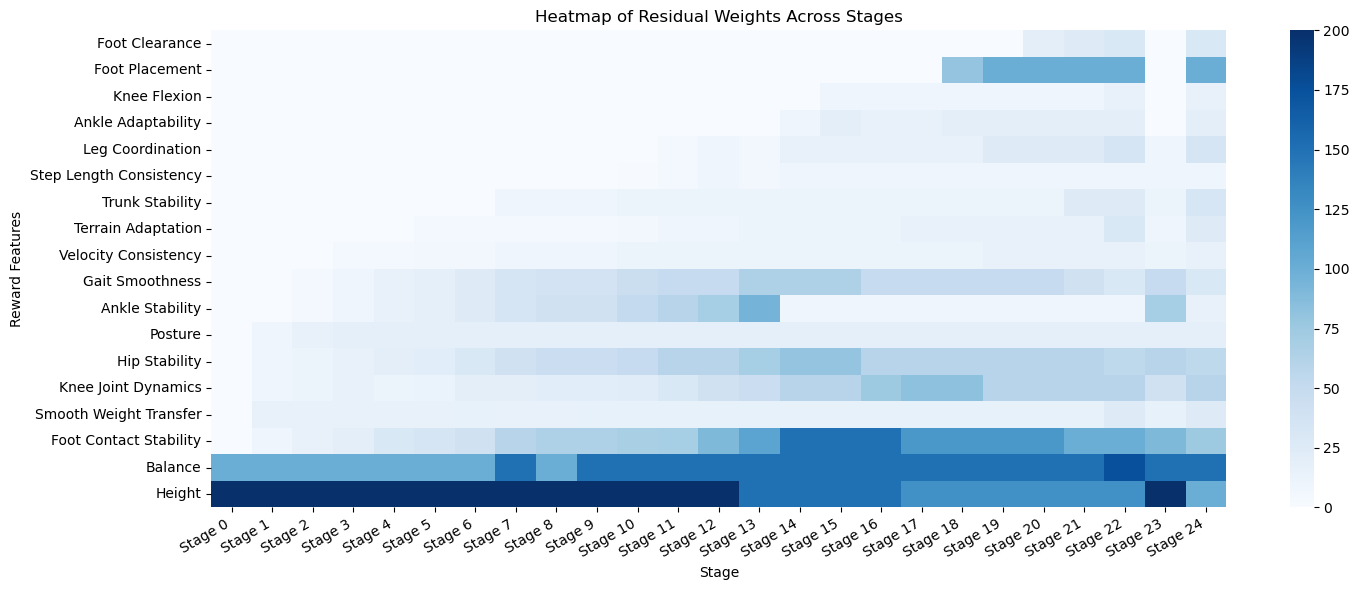

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
sns.heatmap(df[df.columns[::-1]].T, cmap="Blues")
plt.title('Heatmap of Residual Weights Across Stages')
plt.ylabel('Reward Features')
plt.xlabel('Stage')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

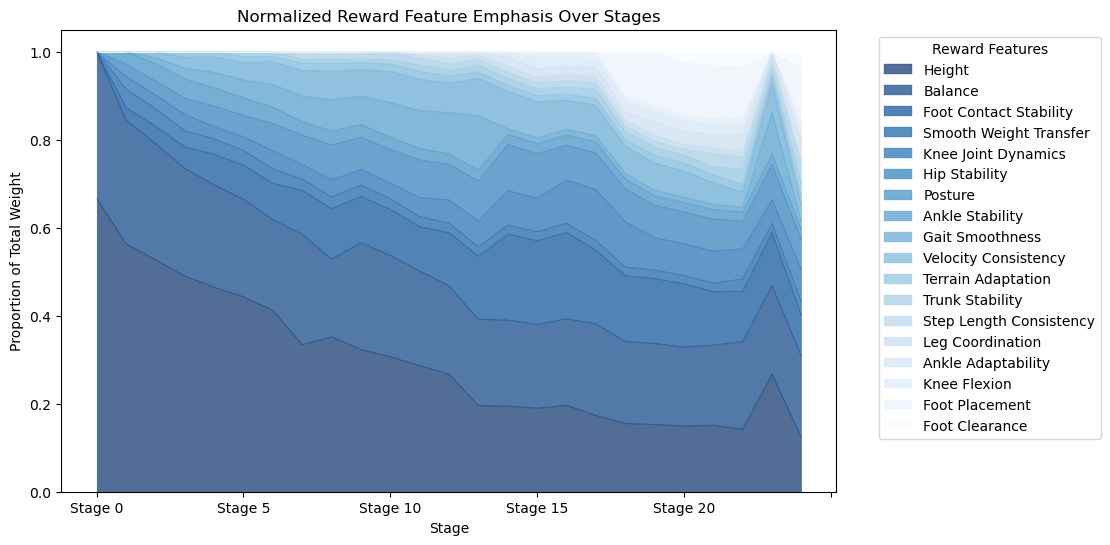

In [87]:
reward_weights_normalized = df.div(df.sum(axis=1), axis=0)

plt.figure()
reward_weights_normalized.plot.area(figsize=(10, 6), colormap="Blues_r", alpha=0.7, linewidth=0.25)
plt.title('Normalized Reward Feature Emphasis Over Stages')
plt.xlabel('Stage')
plt.ylabel('Proportion of Total Weight')
plt.legend(title='Reward Features', loc='upper right', bbox_to_anchor=(1.35, 1))

plt.show()

In [38]:
reward_weights.to_json('reward_weights.json', orient='records', indent=4)

In [62]:
import pandas as pd
import numpy as np
import random

n_stages = 10
np.random.seed(42)
random.seed(42)

def chaotic_walk_weights(start_val, min_val, max_val, noise=10, bias=0, jump_prob=0.05, jump_size=100):
    """Random walk progression with occasional big jumps."""
    vals = [start_val]
    for _ in range(1, n_stages):
        if random.random() < jump_prob:
            change = random.randint(-jump_size, jump_size)
        else:
            change = random.randint(-noise, noise) + bias
        new_val = max(min_val, min(max_val, vals[-1] + change))
        vals.append(new_val)
    return vals

def chaotic_walk(start_val, min_val, max_val, noise=10, bias=0, jump_prob=0.05, jump_size=100, stages=n_stages):
    """Random walk progression with occasional big jumps."""
    vals = [start_val]
    for _ in range(1, stages):
        if random.random() < jump_prob:
            change = random.randint(-jump_size, jump_size)
        else:
            change = random.randint(-noise, noise) + bias
        new_val = max(min_val, min(max_val, vals[-1] + change))
        vals.append(new_val)
    return vals

reward_weights = pd.DataFrame({
    # Core posture & stability
    'Cube Position': chaotic_walk_weights(100, 80, 200, noise=4, jump_prob=0.02, jump_size=50),
    'Cube Orientation': chaotic_walk_weights(0, 0, 100, noise=15, bias=3, jump_prob=0.06, jump_size=80),
    'Grasp': chaotic_walk_weights(0, 0, 200, noise=12, bias=4, jump_prob=0.05, jump_size=25),
}, index=[f"Stage {i}" for i in range(1, n_stages + 1)])

In [63]:
finger = chaotic_walk_weights(0, 0, 200, noise=10, bias=3, jump_prob=0.05, jump_size=60)
reward_weights['Cube Finger Position 1'] = finger
reward_weights['Cube Finger Position 2'] = finger
reward_weights['Cube Finger Position 3'] = finger
reward_weights['Cube Finger Position 4'] = finger
reward_weights['Cube Finger Position 5'] = finger
reward_weights['Cube Grasp Strength'] = chaotic_walk_weights(0, 0, 25, noise=8, bias=3, jump_prob=0.04, jump_size=50)
reward_weights['Elbow Smoothness'] = chaotic_walk_weights(0, 0, 25, noise=8, bias=3, jump_prob=0.04, jump_size=50)
reward_weights['Shoulder Stability'] = chaotic_walk_weights(0, 0, 25, noise=8, bias=3, jump_prob=0.04, jump_size=50)

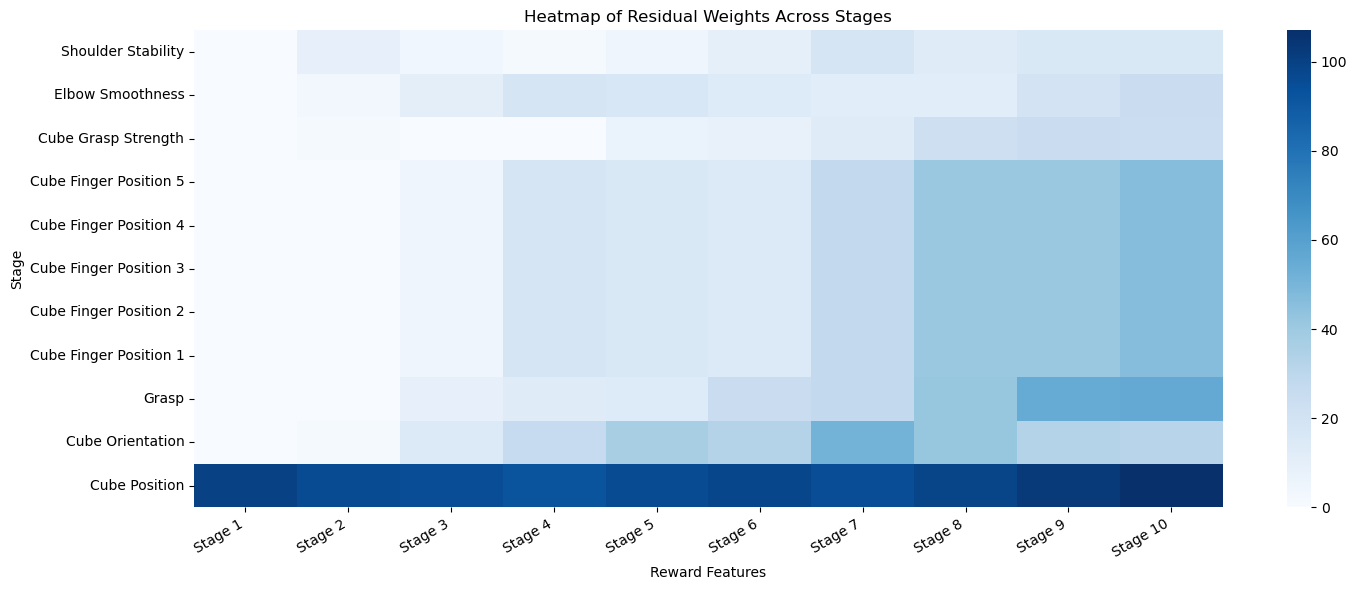

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
sns.heatmap(reward_weights[reward_weights.columns[::-1]].T, cmap="Blues")
plt.title('Heatmap of Residual Weights Across Stages')
plt.xlabel('Reward Features')
plt.ylabel('Stage')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

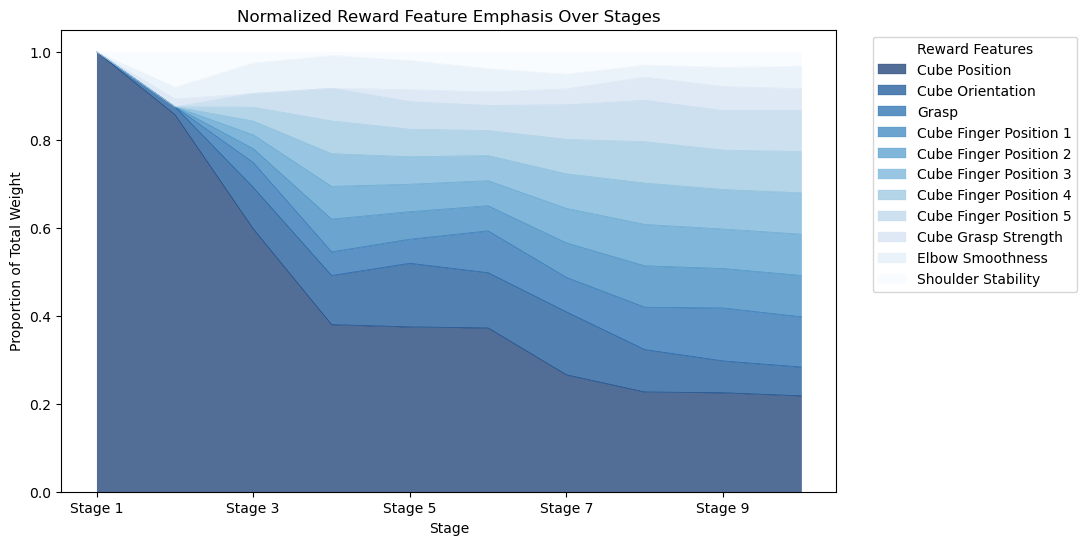

In [65]:
reward_weights_normalized = reward_weights.div(reward_weights.sum(axis=1), axis=0)

plt.figure()
reward_weights_normalized.plot.area(figsize=(10, 6), colormap="Blues_r", alpha=0.7, linewidth=0.25)
plt.title('Normalized Reward Feature Emphasis Over Stages')
plt.xlabel('Stage')
plt.ylabel('Proportion of Total Weight')
plt.legend(title='Reward Features', loc='upper right', bbox_to_anchor=(1.32, 1))

plt.show()